## Causal Comparator: Quickstart Guide

This notebook serves as a practical introduction to the <b>causal comparator</b> package, a tool designed to identify and evaluate structural changes between two causal systems (DAGs).

Whether you are comparing a "Reference" system to a "Treatment" system or monitoring a process over time, this framework helps you distinguish real causal shifts from statistical noise caused by sample size imbalances.

In [ ]:
from causal_comparator.data_generation import EdgePerturbationSimulator
import numpy as np
import lingam 
from lingam.utils import make_dot
from causal_comparator.discovery import CausalComparator
from causal_comparator.metrics import evaluate_binary_classification

In [101]:
# Helper for un-shuffling matrices if your simulator shuffles nodes
def align_matrix(B_est, p):
    idx = np.argsort(p)
    return B_est[idx, :][:, idx]

# Edge Perturbation

In [6]:
# Initialize Simulator
n_nodes = 10
simulator = EdgePerturbationSimulator(n_nodes=n_nodes, noise_type="uniform", rng=np.random.default_rng(42))

# Create graphs: B1_true is the original, B2_true is the modified version as in [1] and [2]
# delta_true marks the exact edges that were removed (edges in B1 not in B2)
B1_true, B2_true, delta_true = simulator.create_graphs(edge_prob=0.2, n_positives=2)

# Generate synthetic data (N1=1000, N2=100) according to [2]
df1, p1 = simulator.simulate_data(B1_true, n_samples=1000)
df2, p2 = simulator.simulate_data(B2_true, n_samples=100)

print(f"Generated data for {n_nodes} nodes.")
print(f"System 1: {df1.shape[0]} samples | System 2: {df2.shape[0]} samples")

Generated data for 10 nodes.
System 1: 1000 samples | System 2: 100 samples


In [ ]:
# Uncomment this line if you want to visualize the graph representation of B1
# make_dot(B1_true)

In [48]:
# Uncomment this line if you want to visualize the graph representation of B2
# make_dot(B2_true)

In [51]:
# Uncomment this line if you want to visualize the graph representation of delta true.
# delta will represent the edges in B1 that are not in B2.
# make_dot(delta_true)

## Causal Comparator

In [20]:
# Initialize Causal Comparator
comparator = CausalComparator(data_i=df1, data_j=df2, model_class=lingam.DirectLiNGAM)


## Execute Naive Estimation

In [ ]:
# Execute Naive Estimation
comparator.estimate_naive()
# Align and Binarize, don't need to align when you aren't simulating data
B1_naive = align_matrix(comparator.freq_i, p1)
B2_naive = align_matrix(comparator.freq_j, p2)

# Logic for Naive: Binary indicator of Removal
# 1 if edge is in B1 and NOT in B2, else 0 as in [1](equation 3)
delta_naive = ((B1_naive == 1) & (B2_naive == 0)).astype(int)

### Evaluation Naive Estimation

In [67]:
# evaluation
scores = evaluate_binary_classification(
                                        y_true=delta_true,
                                        y_scores=delta_naive,
                                        optimize=False
                                        )
print(scores)

{'auc_roc': 0.75, 'aupr': 0.51, 'best_f1': 0.6666666666666666, 'best_threshold': 'N/A', 'precision': 1.0, 'recall': 0.5}


## Execute Bootstrapping

In [64]:
# Method 2: Execute Standard Bootstrap
comparator.estimate_bootstrap(n_sampling=100)

# Align
B1_bs = align_matrix(comparator.freq_i, p1)
B2_bs = align_matrix(comparator.freq_j, p2)

# Calculate the Delta Score in the interval [-1,1]
delta_bs = B1_bs - B2_bs

### Evaluation Bootstrapping

In [65]:
# evaluation
scores = evaluate_binary_classification(
                                        y_true=delta_true,
                                        y_scores=delta_bs,
                                        optimize=True
                                        )
print(scores)

{'auc_roc': 1.0, 'aupr': 1.0, 'best_f1': 1.0, 'best_threshold': np.float64(0.27272727272727276), 'precision': 1.0, 'recall': 1.0}


## Execute RSBS

In [60]:
# Method 3: RSBS (Equal sample-size resampling - Recommended)
comparator.estimate_rsbs(n_sampling=10, seed=42)
# Align the resulting frequency matrices back to the canonical node order
# don't need to align when you aren't simulate data with simulate_data
B1_rsbs = align_matrix(comparator.freq_i, p1)
B2_rsbs = align_matrix(comparator.freq_j, p2)

# Calculate the Delta Score in the interval [-1,1]
delta_rsbs = B1_rsbs - B2_rsbs

### Evaluation RSBS

In [62]:
# evaluation
scores = evaluate_binary_classification(
                                        y_true=delta_true,
                                        y_scores=delta_rsbs,
                                        optimize=True
                                        )
print(scores)

{'auc_roc': 0.9387755102040816, 'aupr': 0.5714285714285714, 'best_f1': 0.5, 'best_threshold': np.float64(0.5050505050505051), 'precision': 0.5, 'recall': 0.5}


## Run Experiments


In [ ]:
import pandas as pd

def run_simulation(n_iterations=20, n1=1000, n2=100, n_nodes=10):
    """
    Refactored simulation runner. 
    Fixes the multiclass error by binarizing the Naive delta for E1 \ E2.
    """
    all_results = []
    
    for seed in range(n_iterations):
        rng = np.random.default_rng(seed)
        simulator = EdgePerturbationSimulator(n_nodes=n_nodes, rng=rng)
        
        # 1. Generate Truth (Canonical) and Shuffled Data (Blind)
        B1_true, B2_true, delta_true = simulator.create_graphs(edge_prob=0.3, n_positives=2)
        df1, p1 = simulator.simulate_data(B1_true, n1)
        df2, p2 = simulator.simulate_data(B2_true, n2)
        
        # 2. Discovery on Shuffled Data
        comparator = CausalComparator(df1, df2)
        
        # Define specific execution and transformation logic for each method
        methods_config = ["Naive", "Bootstrap", "RSBS"]
        
        for name in methods_config:
            # 3. Execute method and retrieve raw results
            if name == "Naive":
                comparator.estimate_naive()
                optimize = False
            elif name == "Bootstrap":
                comparator.estimate_bootstrap(n_sampling=100)
                optimize = True
            else: # RSBS
                comparator.estimate_rsbs(n_sampling=100, seed=seed)
                optimize = True
            
            # 4. Alignment: Map System 1 and System 2 back to canonical space
            B1_aligned = align_matrix(comparator.freq_i, p1)
            B2_aligned = align_matrix(comparator.freq_j, p2)
            
            # 5. Transform to Difference Classification (E1 \ E2)
            if not optimize:
                # For Naive, we must be strictly binary {0, 1}
                # Edge exists in B1 AND NOT in B2
                delta_scores = ((B1_aligned == 1) & (B2_aligned == 0)).astype(int)
            else:
                # For Bootstrap/RSBS, the score is the difference in selection probs
                # Ranges from -1 to 1; optimize loop in metrics.py handles this correctly
                delta_scores = B1_aligned - B2_aligned
            
            # 6. Evaluate using metrics.py
            scores = evaluate_binary_classification(
                y_true=delta_true, 
                y_scores=delta_scores, 
                optimize=optimize
            )
            
            scores.update({"method": name, "seed": seed})
            all_results.append(scores)
            
        print(f"Iteration {seed+1}/{n_iterations} complete.")
            
    return pd.DataFrame(all_results)

In [ ]:
df = run_simulation()

### Plot Results


In [ ]:
from causal_comparator.plotting import plot_ranking_metrics, plot_summary_performance, plot_classification_metrics

fig1 = plot_ranking_metrics(df, save_path="results_ranking.html")
fig2 = plot_summary_performance(df, save_path="results_summary.html")
fig3 = plot_classification_metrics(df, save_path="results_classification.html")

# Mechanisms Perturbation

In [27]:
import numpy as np
import lingam 
from lingam.utils import make_dot
from causal_comparator.data_generation import MechanismPerturbationSimulator
from causal_comparator.discovery import CausalComparator



In [ ]:
rng = np.random.default_rng(10)
# Initialize Mechanism Simulator
# We perturb 2 nodes, adding & removing 1 parent for each (n_positives=1)
n_nodes = 5
simulator = MechanismPerturbationSimulator(n_nodes=n_nodes, rng=rng)
B1_true, B2_true, y_true_nodes = simulator.create_graphs(
    edge_prob=0.6, 
    n_perturbed_nodes=1, 
    n_positives=1
)

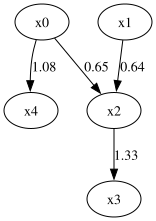

In [13]:
make_dot(B1_true)

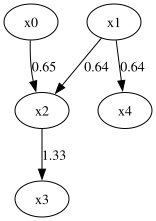

In [14]:
make_dot(B2_true)

In [15]:
y_true_nodes

array([0, 0, 0, 0, 1])

In this case x4 was perturbed. In fact x0 isn't x4's parent anymore (deletion) while x1 is now the new parent (addition). 

In [16]:
n_nodes = 10
sim = MechanismPerturbationSimulator(n_nodes=n_nodes)
B1, B2, y_true = sim.create_graphs(edge_prob=0.3, n_perturbed_nodes=3, n_positives=1)

# Identify rows where B1 and B2 are not identical
# We sum the absolute differences per row
row_diffs = np.sum(np.abs(B1 - B2), axis=1)




In [18]:
# Indices where row_diffs > 0 should match indices where y_true == 1
calculated_perturbed_indices = np.where(row_diffs > 0)[0]
true_perturbed_indices = np.where(y_true == 1)[0]


In [19]:
true_perturbed_indices

array([3, 6, 8])

In [20]:
calculated_perturbed_indices

array([3, 6, 8])

In [22]:
np.sort(calculated_perturbed_indices)
np.sort(true_perturbed_indices)

array([3, 6, 8])

## Run Experiments with Simulated Data

In [108]:
from causal_comparator.metrics import calculate_node_scores, evaluate_binary_classification
import pandas as pd

In [ ]:
def run_node_level_experiment_2(
    n_iterations: int = 10, 
    n_nodes: int = 15, 
    n1: int = 1000, 
    n2: int = 500
) -> pd.DataFrame:
    all_results = []

    for seed in range(n_iterations):
        rng = np.random.default_rng(seed)
        simulator = MechanismPerturbationSimulator(n_nodes=n_nodes, rng=rng)
        B1_true, B2_true, y_true_nodes = simulator.create_graphs(
            edge_prob=0.4, 
            n_perturbed_nodes=5, 
            n_positives=2
        )
        
        df1, p1 = simulator.simulate_data(B1_true, n1)
        df2, p2 = simulator.simulate_data(B2_true, n2)
        
        comparator = CausalComparator(df1, df2, model_class=lingam.DirectLiNGAM)
        
        methods_config = ['Naive', 'Bootstrap', 'RSBS']
        benchmarks = {}

        for name in methods_config:
            # 1. Trigger the discovery for each method
            if name == 'Naive':
                comparator.estimate_naive()
            elif name == 'Bootstrap':
                comparator.estimate_bootstrap(n_sampling=100)
            else:
                comparator.estimate_rsbs(n_sampling=100)

            # 2. ALIGNMENT: Use p1 and p2 to move both systems to Canonical Space
            # This fixes the bug where Node X in df1 was compared to Node Y in df2
            B1_aligned = align_matrix(comparator.freq_i, p1)
            B2_aligned = align_matrix(comparator.freq_j, p2)

            # 3. Calculate the correct Delta in ground-truth space
            delta_canonical = B2_aligned - B1_aligned

            # 4. Aggregate into node scores (already in ground-truth order)
            benchmarks[name] = calculate_node_scores(delta_canonical, mode='incoming')

        # Evaluation Phase
        for method_name, scores in benchmarks.items():
            # No [idx_recovery] needed here! The scores are already aligned to y_true_nodes
            metrics = evaluate_binary_classification(
                y_true_nodes, 
                scores, 
                optimize=True
            )
            
            all_results.append({
                'seed': seed,
                'method': method_name,
                **metrics
            })
        print(f"Iteration {seed+1}/{n_iterations} complete.")
        
    return pd.DataFrame(all_results)

In [109]:
results_df = run_node_level_experiment_2(n_iterations = 20, n_nodes = 15, n1=1000, n2=200)

Iteration 1/20 complete.
Iteration 2/20 complete.
Iteration 3/20 complete.
Iteration 4/20 complete.
Iteration 5/20 complete.
Iteration 6/20 complete.
Iteration 7/20 complete.
Iteration 8/20 complete.
Iteration 9/20 complete.
Iteration 10/20 complete.
Iteration 11/20 complete.
Iteration 12/20 complete.
Iteration 13/20 complete.
Iteration 14/20 complete.
Iteration 15/20 complete.
Iteration 16/20 complete.
Iteration 17/20 complete.
Iteration 18/20 complete.
Iteration 19/20 complete.
Iteration 20/20 complete.


In [110]:
from causal_comparator.plotting import plot_ranking_metrics, plot_summary_performance, plot_classification_metrics

fig1 = plot_ranking_metrics(results_df, save_path="results_ranking_nodes_8_fixed.html")
fig2 = plot_summary_performance(results_df, save_path="results_summary_nodes_8_fixed.html")
fig3 = plot_classification_metrics(results_df, save_path="results_classification_nodes_8_fixed.html")

In [111]:
fig1.show()

In [112]:
fig2.show()

In [113]:
fig3.show()

## References
[1] Ma, Sisi, and Roshan Tourani. "Comparing Causal Bayesian Networks Estimated from Data." Entropy 26.3 (2024): 228.

[2] Shimizu, Shohei, et al. "DirectLiNGAM: A direct method for learning 
a linear non-Gaussian structural equation model." Journal of Machine 
Learning Research-JMLR 12.Apr (2011): 1225-1248.